# Exercises TANA - 8 October 2025

The goals of this exercise notebook are to:

- Get familiar with the ```galpy.orbit``` framework
- Study bound and unbound orbits and their properties

Good luck! In case of questions, ask us during the exercise sessions or send an e-mail to andrea.gebek@ugent.be and nikolaos.andreadis@ugent.be (the chances of a swift response increase if you include both of us). We're here to help you out!

In [1]:
import numpy as np
import astropy.constants as c
import matplotlib.pyplot as plt
from astropy.units import km, au, pc, kpc, s, yr, Myr, Gyr, Msun, rad, kg, J

Galpy, among other things, lets you initiate an orbit (i.e., define the initial conditions) and integrate its trajectory within a certain potential.

In [2]:
from galpy.orbit import Orbit

You can either initiate the orbit of a known object (e.g., Milky Way satellite galaxies, globular clusters, etc.) or set your own initialization completely from scratch.

Let's start with integrating the orbit of the [Caldwell 84](https://en.wikipedia.org/wiki/NGC_5286) globular cluster in the potential of the MW:

In [3]:
o1 = Orbit.from_name('NGC5286')

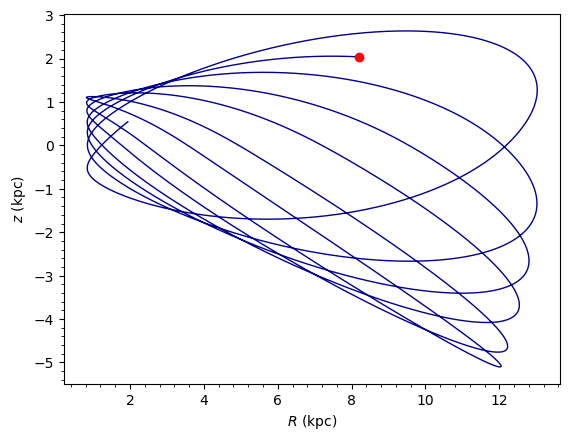

In [4]:
from galpy.potential import MWPotential2014
ts = np.linspace(0.,1,100000)*Gyr
o1.integrate(ts,MWPotential2014)

o1.plot(lw=1, c='darkblue');
plt.plot([o1.R().to_value()],[o1.z().to_value()],'ro');

You can retrieve the orbit's so you can make your own plot, instead of using galpy's internal plotting function using: ```o1.R(ts)``` and ```o1.z(ts)```

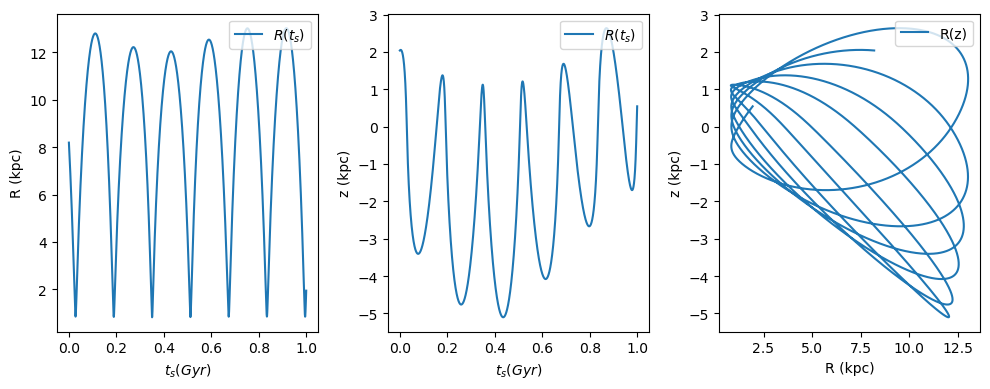

In [5]:
# Give it a try!

R = o1.R(ts)
z = o1.z(ts)

fig, axs = plt.subplots(1,3, figsize=(10,4))

axs[0].plot(ts, R, label = r'$R(t_s)$')
axs[0].set_xlabel(r'$t_s (Gyr)$')
axs[0].set_ylabel('R (kpc)')
axs[0].legend(loc='upper right')

axs[1].plot(ts, z, label = r'$R(t_s)$')
axs[1].set_xlabel(r'$t_s (Gyr)$')
axs[1].set_ylabel('z (kpc)')
axs[1].legend(loc='upper right')

axs[2].plot(R, z, label = 'R(z)')
axs[2].set_xlabel('R (kpc)')
axs[2].set_ylabel('z (kpc)')
axs[2].legend(loc='upper right')

fig.tight_layout()  # <-- call it on the figure, not the axes
plt.show()

Let's now initialize our own object!

In galpy, in three dimensions initial conditions are given either as ```[R,vR,vT,z,vz,phi]``` or one can choose not to specify the azimuth of the orbit and initialize with ```[R,vR,vT,z,vz]```. In two dimensions, we can similarly specify fully two-dimensional orbits ```o=Orbit([R,vR,vT,phi])``` or choose not to track the azimuth and initialize with ```o=Orbit([R,vR,vT])```. ```Orbit()``` automatically figures out the dimensionality of the space from the initial conditions in this case.

In [6]:
o2 = Orbit([6.7*kpc, 12.5*km/s, 170*km/s, -3*kpc, 45*km/s, 6*rad])

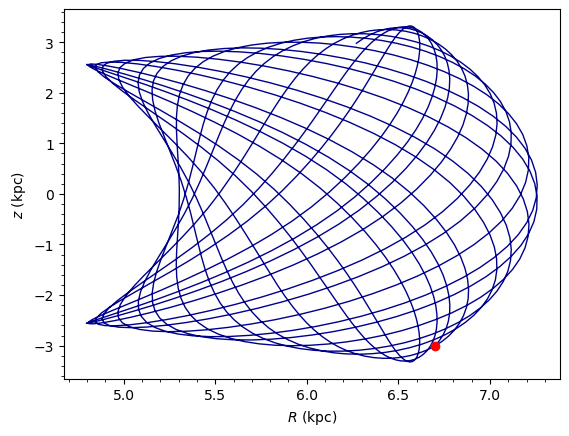

In [7]:
from galpy.potential import MWPotential2014

ts = np.linspace(0.,2,1000)*Gyr
o2.integrate(ts,MWPotential2014)

o2.plot(lw=1, c='darkblue');
plt.plot([o2.R().to_value()],[o2.z().to_value()],'ro');

Let's look at the system's energy, using ```o.E()```. How does it change throughout the orbit?

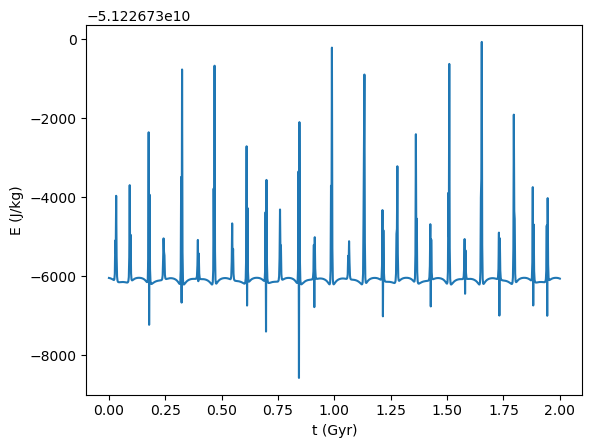

In [8]:
plt.plot(ts, o2.E(ts).to(J/kg));
plt.xlabel('t (Gyr)');
plt.ylabel('E (J/kg)');
#plt.ylim(-6e10, 0); #Tiny fluctuations

You can also check what happens in the vertical dimension:

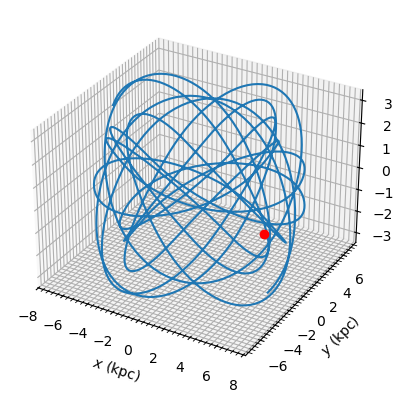

In [9]:
o2.plot3d();
plt.plot([o2.R().to_value()],[o2.z().to_value()],'ro');

__Be very careful with the units!__

## Task 1: Orbits around the Plummer potential

Assume a _Plummer_ potential:

$\Phi(r) = -\dfrac{\mathrm{amp}}{\sqrt{r^2+b^2}}, \quad amp = G\cdot M$

with: $\quad amp=1\;M_\odot \quad\&\quad b=1\;AU \quad$ and initialize an orbit at: $\quad r=1\;AU \quad v_R=0 \quad v_T=30 \; km/s \quad \phi=\pi$.

- Integrate this orbit and see what it looks like. Over what time should you integrate it, given the system's units? Verify, by plotting the energy as a function of time, that your timestep and time range choices are sane.
- Calculate the pericentre and apocentre of this orbit and overplot them on top of it. Do they match?[<sup>*</sup>](#fn)
- Vary both the amplitude and the scale length and plot the orbits that you get. Is there any interesting limit case? What happens there? Why?
- For a fixed amplitude, plot the values of the apocentre and pericentre as a function of the scale length. Do the same for the eccentricity.

<sup id="fn">*</sup>Note that you can also double-check an orbit's apocentre and pericentre with galpy: ```o.rap()``` & ```o.rperi()```</span>

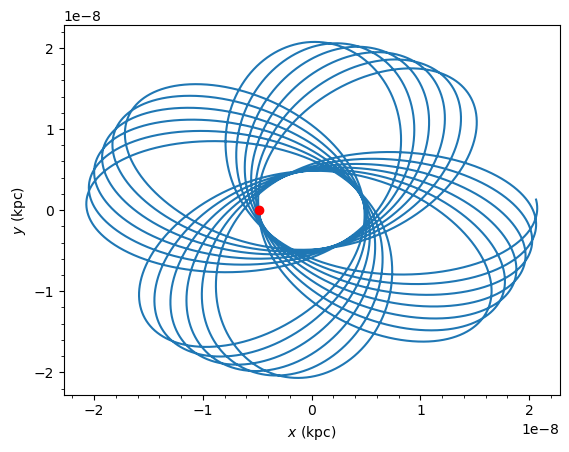

In [27]:
from galpy.potential import PlummerPotential

ts = np.linspace(0.,100,100000)*yr
amp = 1*Msun
b = 1*au
o3 = Orbit([1*au, 0*km/s, 30*km/s, np.pi*rad])

plummer_pot = PlummerPotential(amp=amp, b=b)
o3.integrate(ts,plummer_pot)

apocenter = o3.rap()
pericenter = o3.rperi()

o3.plot(d1='x', d2='y')
plt.plot([o3.x().to_value()],[o3.y().to_value()],'ro');
plt.show()

(-300000000.0, 0.0)

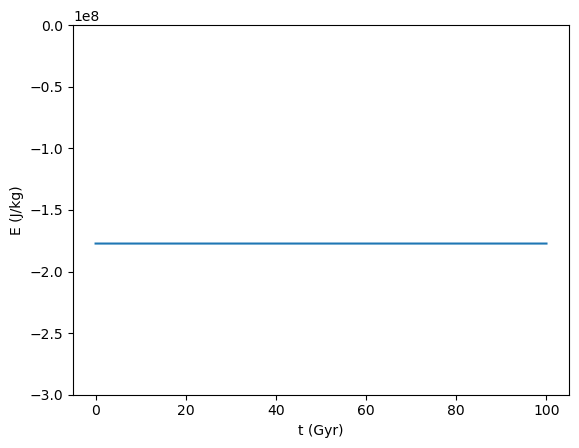

In [18]:
#Energy of the system

plt.plot(ts, o3.E(ts).to(J/kg));
plt.xlabel('t (Gyr)');
plt.ylabel('E (J/kg)');
plt.ylim(-3e8, 0)

AttributeError: Line2D.set() got an unexpected keyword argument 'axis'

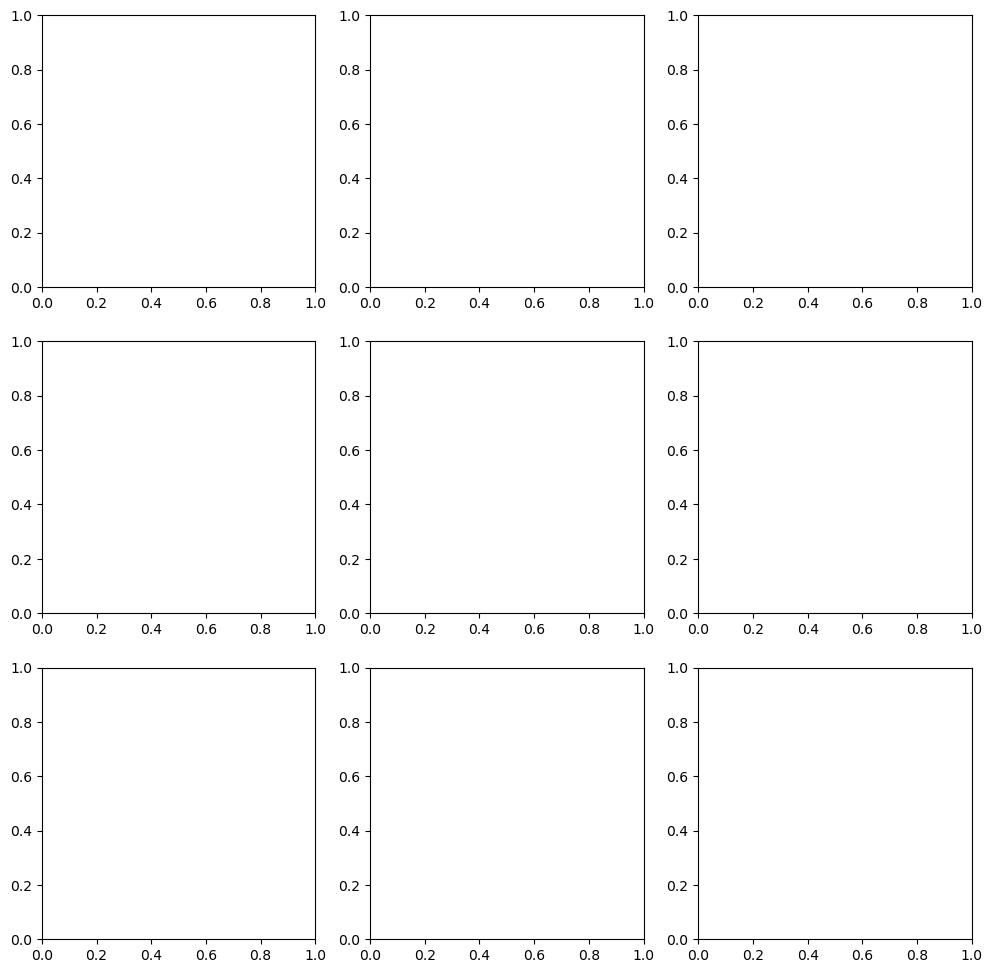

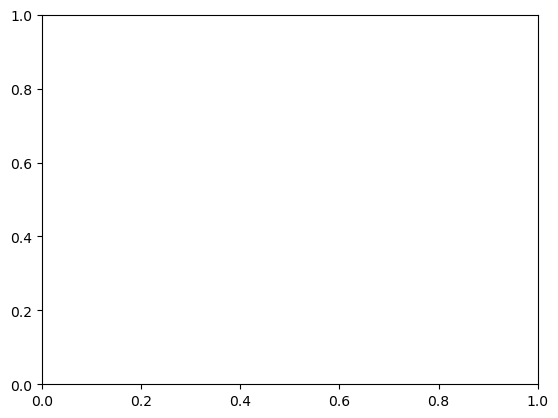

In [33]:
amplitude = [1, 2, 3]*Msun
b_param = [1, 2, 3]*au
o3 = Orbit([1*au, 0*km/s, 30*km/s, np.pi*rad])

fig, axs = plt.subplots(3,3, figsize=(12,12))

for i, amp in enumerate(amplitude):
    for j, b in enumerate(b_param):
        plummer_pot = PlummerPotential(amp=amp, b=b)
        o3.integrate(ts,plummer_pot)
        o3.plot(d1='x', d2='y', axis = axs[i][j])
plt.plot([o3.x().to_value()],[o3.y().to_value()],'ro');
plt.show()

## Task 2: Orbits in an axisymmetric potential

Now let's study an axisymmetric potential, and specifically, we'll look at the Miyamoto-Nagai potential.
Import the potential and define an orbit by setting the initial conditions: [$R$, $v_R$, $v_T$, $z$, $v_z$, $\phi$]. How can you make sure that your orbit is bound? You will also need to choose a time interval for the numerical orbit integration. To inform your time interval choice, calculate the radial period of your orbit **before** numerically integrating it.
*Hint:* once you specify galpy potential and orbit objects, you can directly calculate the radial period using: ```orbit.Tr(analytic = True, pot = potential)```.

*Note that for specific choices of potentials/orbits it is possible that the calculation of the radial period within galpy doesn't converge and yields warnings and potentially ```nan``` values. In that case try to modify the numerical values of your potential/orbit such that it broadly ressembles the orbit of the sun in the Milky Way.

Numerically integrate the orbit over one radial period. Plot the orbit in the $x-y$ plane and in cylindrical coordinates, $R-z$.

In [12]:
# Your code here :)

Next, consider the azimuthal period. What do you note when integrating the orbit over one azimuthal period?
*Hint:* Once you specify galpy potential and orbit objects, you can directly calculate the azimuthal period using: ```orbit.Tp(analytic = True, pot = potential)```.

Plot the orbit over many radial periods ($\sim10$). You'll note that there's spaces that the orbit never crosses. In the meridional plane (the $R-z$-plane), the "forbidden space" can be characterized by the ZVC (zero-velocity curve). Overplot the ZVC on your orbit in cylindrical coordinates.
*Hint:* You can access the ZVC and the range of radii over which the ZVC can be calculated using: ```potential.zvc()``` and ```potential.zvc_range()```.

In [13]:
# Your code here :)

Finally, systematically vary the initial conditions $z$ and $v_z$ of your orbit and check how the resulting orbits and ZVCs change.

In [14]:
# Your code here :)